In [3]:
import pickle
import numpy as np
import pandas as pd
from hmmlearn import hmm
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [4]:
train_data = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/working_data/5s_0.5.csv')
test_data = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/meta_test_data/5s_0.5.csv')

features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/three_class_raw_5s_yo_0.5.csv')

with open('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/imb_files/final_hpt_choices.pkl', 'rb') as f:
    final_choices = pickle.load(f)

Get the groups in the test data to make sure that the same experiments are selected as the true label for validating the state-space classifier.

In [5]:
groups = test_data['experiment_id']

features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
features_test = features[features['experiment_id'].isin(groups)]

X_test_3_class = features_test.drop(['experiment_id', 'label'], axis=1)
y_test_3_class = features_test['label']

In [6]:
# Prepare training and testing data
X_train = train_data.drop(columns=['label', 'experiment_id'])
y_train = train_data['label']

X_test = test_data.drop(columns=['label', 'experiment_id'])
y_test = test_data['label']

In [7]:
# Get the tuned model parameters, selected model and imbalanced handling technique
tuned_model_imb_params = final_choices['5s_0.5']
params = tuned_model_imb_params['params']

In [8]:
# model = RandomForestClassifier(
#         n_estimators=int(params['n_estimators']),
#         max_depth=int(params['max_depth']),
#         min_samples_split=int(params['min_samples_split']),
#         min_samples_leaf=int(params['min_samples_leaf']),
#         max_features=params['max_features'],
#         bootstrap=params['bootstrap']
#     )

In [9]:
# # Apply the sampler
# sampler = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

In [10]:
# # Encode labels
# label_encoder = LabelEncoder()
# y_train_encoded = label_encoder.fit_transform(y_train_resampled)

In [11]:
# model.fit(X_train_resampled, y_train_encoded)
# y_pred = label_encoder.inverse_transform(model.predict(X_test))

In [12]:
# class_names = ['void', 'non-void']
# # Confusion matrix
# cm = confusion_matrix(y_test, y_pred, labels=class_names)
# cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['void', 'non-void'])
# cm_display.plot()
# plt.title(f'Confusion Matrix: 5s_0.5')
# plt.show()
    
    
# print(f"Classification Report: 5s_0.5")
# print(classification_report(y_test, y_pred, labels=class_names))
# print("Accuracy:", accuracy_score(y_test, y_pred))

In [13]:
# y_pred_prob = model.predict_proba(X_test)

In [14]:
# y_pred_prob


In [15]:
# y_pred_prob_df = pd.DataFrame(y_pred_prob, columns=class_names)
# y_pred_prob_df['experiment_id'] = test_data['experiment_id'].values
# y_pred_prob_df.to_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/predictions/5s_0.5_probabilities.csv', index=False)

In [16]:
probs = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/predictions/5s_0.5_probabilities_correct_order.csv')
void_probs_exp_ids = probs.drop(columns=['non-void'])

In [17]:
def preset_emission_probabilities(df, prob_col='void', id_col='experiment_id', n_states=3):
    # transmat = np.array([
    #     [0.8, 0.2, 0.0],  # pre-void
    #     [0.0, 0.8, 0.2],  # void
    #     [0.0, 0.0, 1.0]   # post-void (absorbing)
    # ])
    
    transmat = np.array([
        [0.7, 0.3, 0.0],    # pre-void -> mostly stay, can go to void
        [0.0, 0.90, 0.1],    # void -> mostly stay, can go to post-void
        [0.0, 0.0, 1.0]     # post-void -> terminal
    ])


    # Emission probabilities
    # Each row corresponds to a hidden state:
    # [P(non-void|state), P(void|state)]
    emissionprob = np.array([
        [0.9, 0.1],  # pre-void mostly emits non-void
        [0.2, 0.8],  # void mostly emits void
        [0.8, 0.2]   # post-void mostly emits non-void again
    ])

    # Start probabilities
    startprob = np.array([1.0, 0.0, 0.0])  # always start in pre-void

    # Step 3: Create and apply the model
    model = hmm.CategoricalHMM(
        n_components=n_states,
        init_params="",
        n_iter=10
    )

    model.startprob_ = startprob
    model.transmat_ = transmat
    model.emissionprob_ = emissionprob


    # Step 5: Map numeric states to labels
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    all_results = []
    
    for exp_id, group in df.groupby(id_col):
        # observations = group[prob_col].to_numpy().reshape(-1, 1)
        observations = (group[prob_col] >= 0.37).astype(int).to_numpy().reshape(-1, 1)
        # Step 4: Decode hidden states
        logprob, hidden_states = model.decode(observations, algorithm="viterbi")
        state_sequence = [state_map[s] for s in hidden_states]
        
        # Store results with original index to preserve order
        group_result = group.copy()
        group_result['predicted_state'] = state_sequence
        all_results.append(group_result)
        

    # Combine back into one dataframe
    # return pd.concat(all_results).sort_index()
    return pd.concat(all_results)

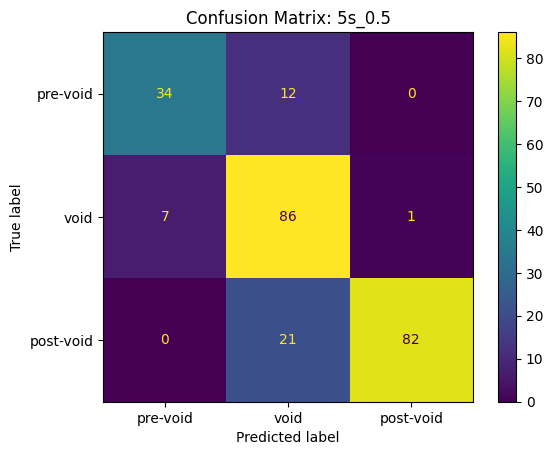

              precision    recall  f1-score   support

    pre-void       0.83      0.74      0.78        46
        void       0.72      0.91      0.81        94
   post-void       0.99      0.80      0.88       103

    accuracy                           0.83       243
   macro avg       0.85      0.82      0.82       243
weighted avg       0.86      0.83      0.83       243

Accuracy: 0.831275720164609


In [18]:
df = preset_emission_probabilities(void_probs_exp_ids, n_states=3)
state_preds = df['predicted_state'].values

# Confusion matrix
cm = confusion_matrix(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void'])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['pre-void', 'void', 'post-void'])
cm_display.plot()
plt.title(f'Confusion Matrix: 5s_0.5')
plt.show()

# Classification report
print(classification_report(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void']))
print("Accuracy:", accuracy_score(y_test_3_class, state_preds))


In [ ]:
import numpy as np
import pandas as pd
from hmmlearn import hmm

def learn_emission_probabilities(df, prob_col='void', id_col='experiment_id', n_states=3):
    # Fixed Transition Matrix
    # transmat = np.array([
    #     [0.8, 0.2, 0.0],  # pre-void → pre-void or void
    #     [0.0, 0.8, 0.2],  # void → void or post-void
    #     [0.0, 0.0, 1.0]   # post-void absorbing
    # ])
    
    transmat = np.array([
        [0.7, 0.3, 0.0],    # pre-void -> mostly stay, can go to void
        [0.0, 0.90, 0.1],    # void -> mostly stay, can go to post-void
        [0.0, 0.0, 1.0]     # post-void -> terminal
    ])

    # Start probabilities (fixed)
    startprob = np.array([1.0, 0.0, 0.0])

    # Build model: 'e' means emissions are free to be learned
    model = hmm.CategoricalHMM(
        n_components=n_states,
        init_params="e",  # only emissions will be learned
        n_iter=100,
        tol=1e-4,
        random_state=5
    )

    # Assign fixed parameters
    model.startprob_ = startprob
    model.transmat_ = transmat

    # Combine all observations for fitting
    all_obs = []
    lengths = []

    for _, group in df.groupby(id_col):
        observations = (group[prob_col] >= 0.35).astype(int).to_numpy().reshape(-1, 1)
        all_obs.append(observations)
        lengths.append(len(observations))

    all_obs = np.vstack(all_obs)

    # Fit model — only emissions will be updated
    model.fit(all_obs, lengths)

    # Map numeric states to labels
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    all_results = []

    for exp_id, group in df.groupby(id_col):
        observations = (group[prob_col] >= 0.35).astype(int).to_numpy().reshape(-1, 1)
        _, hidden_states = model.decode(observations, algorithm="viterbi")
        group_result = group.copy()
        group_result['predicted_state'] = [state_map[s] for s in hidden_states]
        all_results.append(group_result)

    return pd.concat(all_results), model.emissionprob_

[0 0 0 1 1 1 1 1 1 1 1 1 1]
[0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2]
[0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2]
[0 0 0 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2]
[0 0 0 0 0 0 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2]
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2]
[0 0 0 1 1 1 1 1 1 1 1 1 1 1 1]


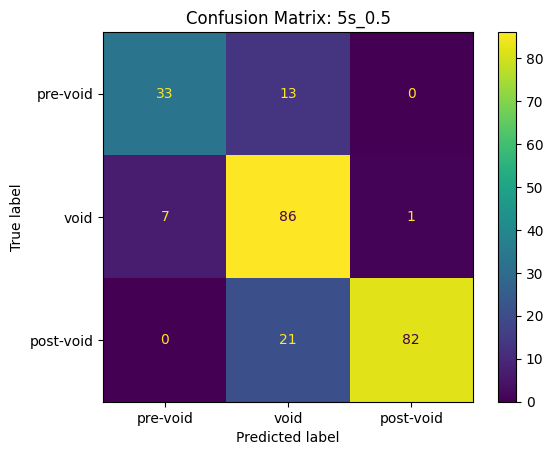

              precision    recall  f1-score   support

    pre-void       0.82      0.72      0.77        46
        void       0.72      0.91      0.80        94
   post-void       0.99      0.80      0.88       103

    accuracy                           0.83       243
   macro avg       0.84      0.81      0.82       243
weighted avg       0.85      0.83      0.83       243

Accuracy: 0.8271604938271605


In [22]:
test_state_preds, em = learn_emission_probabilities(void_probs_exp_ids, n_states=3)
state_preds = test_state_preds['predicted_state'].values

# Confusion matrix
cm = confusion_matrix(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void'])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['pre-void', 'void', 'post-void'])
cm_display.plot()
plt.title(f'Confusion Matrix: 5s_0.5')
plt.show()

# Classification report
print(classification_report(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void']))
print("Accuracy:", accuracy_score(y_test_3_class, state_preds))

In [49]:
em

array([[0.81146844, 0.18853156],
       [0.03449369, 0.96550631],
       [0.90569003, 0.09430997]])

In [50]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
print(test_state_preds)

         void  experiment_id predicted_state
0    0.387671              5        pre-void
1    0.367105              5        pre-void
2    0.346253              5        pre-void
3    0.566022              5            void
4    0.465052              5            void
5    0.534021              5            void
6    0.844842              5            void
7    0.771499              5            void
8    0.501037              5            void
9    0.537376              5            void
10   0.386443              5            void
11   0.419550              5            void
12   0.313829              5       post-void
13   0.127831              9        pre-void
14   0.166050              9        pre-void
15   0.386172              9            void
16   0.597722              9            void
17   0.601546              9            void
18   0.639488              9            void
19   0.554347              9            void
20   0.695082              9            void
21   0.762

In [21]:
# to CSV
# test_state_preds.to_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/predictions/5s_0.5_hmm_predictions_global_emissions.csv', index=False)
# em_df = pd.DataFrame(em, columns=['pre-void', 'void', 'post-void'])
# em_df.index.name = 'state'
# em_df.to_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/predictions/5s_0.5_hmm_emissions.csv')

# Random seed for reproducibility.

In [22]:
import numpy as np
import pandas as pd
from hmmlearn import hmm

def implementation_2_best_seed(df, prob_col='void', id_col='experiment_id', n_states=3, seeds=range(200)):
    transmat = np.array([
        [0.7, 0.3, 0.0],    # pre-void -> mostly stay, can go to void
        [0.0, 0.90, 0.1],   # void -> mostly stay, can go to post-void
        [0.0, 0.0, 1.0]     # post-void -> terminal
    ])
    
    
    startprob = np.array([1.0, 0.0, 0.0])

    # Prepare combined observations once
    all_obs = []
    lengths = []
    for _, group in df.groupby(id_col):
        observations = (group[prob_col] >= 0.35).astype(int).to_numpy().reshape(-1, 1)
        all_obs.append(observations)
        lengths.append(len(observations))
    all_obs = np.vstack(all_obs)

    best_score = -np.inf
    best_model = None

    # Try multiple seeds and keep the best
    for seed in seeds:
        model = hmm.CategoricalHMM(
            n_components=n_states,
            init_params="e",  # only emissions will be learned
            n_iter=100,
            tol=1e-4,
            random_state=seed
        )
        model.startprob_ = startprob
        model.transmat_ = transmat

        model.fit(all_obs, lengths)
        score = model.score(all_obs, lengths)

        if score > best_score:
            best_score = score
            best_model = model
            best_seed = seed

    # Decode using the best model
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    all_results = []
    for exp_id, group in df.groupby(id_col):
        observations = (group[prob_col] >= 0.35).astype(int).to_numpy().reshape(-1, 1)
        _, hidden_states = best_model.decode(observations, algorithm="viterbi")
        group_result = group.copy()
        group_result['predicted_state'] = [state_map[s] for s in hidden_states]
        all_results.append(group_result)

    return pd.concat(all_results), best_model.emissionprob_, best_score, best_seed



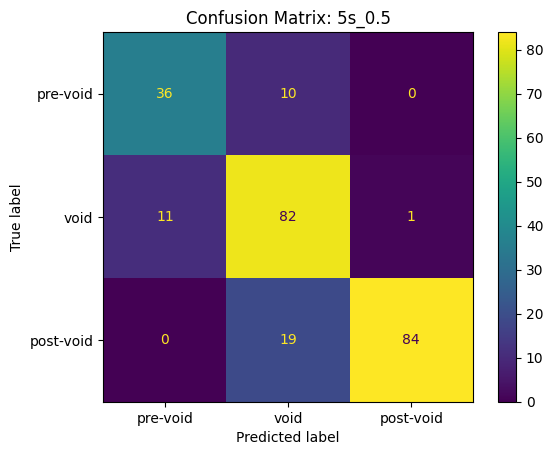

              precision    recall  f1-score   support

    pre-void       0.77      0.78      0.77        46
        void       0.74      0.87      0.80        94
   post-void       0.99      0.82      0.89       103

    accuracy                           0.83       243
   macro avg       0.83      0.82      0.82       243
weighted avg       0.85      0.83      0.83       243

Accuracy: 0.831275720164609
Best seed: 42, Best score: -100.66373914059064


In [23]:
best_test_state_preds, best_emissionprob, best_score, best_seed = implementation_2_best_seed(void_probs_exp_ids, n_states=3, seeds=range(200))
state_preds = best_test_state_preds['predicted_state'].values

# Confusion matrix
cm = confusion_matrix(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void'])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['pre-void', 'void', 'post-void'])
cm_display.plot()
plt.title(f'Confusion Matrix: 5s_0.5')
plt.show()

# Classification report
print(classification_report(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void']))
print("Accuracy:", accuracy_score(y_test_3_class, state_preds))

print(f"Best seed: {best_seed}, Best score: {best_score}")

## Gaussian 

In [51]:
import numpy as np
import pandas as pd
from hmmlearn import hmm

def implementation_gaussian_best_seed(df, prob_col='void', id_col='experiment_id', n_states=3, seeds=[0, 42, 100, 1234]):
    # transmat = np.array([
    #     [0.7, 0.3, 0.0],    # pre-void -> mostly stay, can go to void
    #     [0.0, 0.90, 0.1],   # void -> mostly stay, can go to post-void
    #     [0.0, 0.0, 1.0]     # post-void -> terminal
    # ])
    
    transmat = np.array([
        [0.8, 0.2, 0.0],  # pre-void → pre-void or void
        [0.0, 0.8, 0.2],  # void → void or post-void
        [0.0, 0.0, 1.0]   # post-void absorbing
    ])

    startprob = np.array([1.0, 0.0, 0.0])

    # Combine observations
    all_obs = []
    lengths = []
    for _, group in df.groupby(id_col):
        # GaussianHMM takes float inputs (continuous), so no thresholding
        observations = group[prob_col].to_numpy().reshape(-1, 1)
        all_obs.append(observations)
        lengths.append(len(observations))

    all_obs = np.vstack(all_obs)
    
    best_score = -np.inf
    best_model = None
    
    for seed in seeds:        
        model = hmm.GaussianHMM(
        n_components=n_states,
        init_params="mc",  # learn means & covariances, keep trans/start fixed
        n_iter=100,
        tol=1e-4,
        random_state=seed
        )
        model.startprob_ = startprob
        model.transmat_ = transmat

        model.fit(all_obs, lengths)
        score = model.score(all_obs, lengths)

        if score > best_score:
            best_score = score
            best_model = model
            best_seed = seed

    model.fit(all_obs, lengths)

    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    all_results = []
    for exp_id, group in df.groupby(id_col):
        observations = group[prob_col].to_numpy().reshape(-1, 1)
        _, hidden_states = best_model.decode(observations, algorithm="viterbi")
        group_result = group.copy()
        group_result['predicted_state'] = [state_map[s] for s in hidden_states]
        all_results.append(group_result)

    # return pd.concat(all_results), model.means_, model.covars_
    return pd.concat(all_results), best_model.means_, best_model.covars_, best_score, best_seed

Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


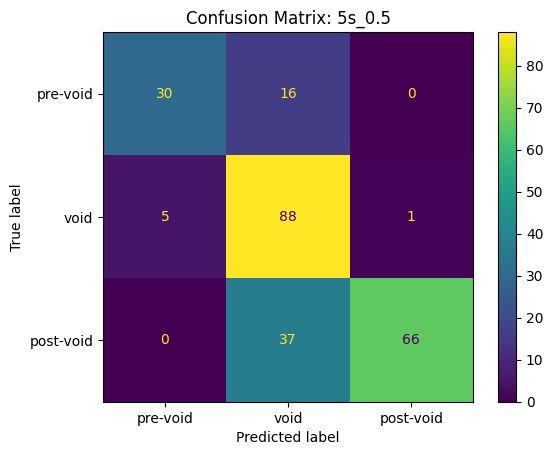

              precision    recall  f1-score   support

    pre-void       0.86      0.65      0.74        46
        void       0.62      0.94      0.75        94
   post-void       0.99      0.64      0.78       103

    accuracy                           0.76       243
   macro avg       0.82      0.74      0.76       243
weighted avg       0.82      0.76      0.76       243

Accuracy: 0.757201646090535
Best seed: 500, Best score: 170.45962354291927


In [52]:
best_test_state_preds, best_model_means, best_model_covars, best_score, best_seed = implementation_gaussian_best_seed(void_probs_exp_ids, n_states=3, seeds=range(1234))
state_preds = best_test_state_preds['predicted_state'].values

# Confusion matrix
cm = confusion_matrix(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void'])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['pre-void', 'void', 'post-void'])
cm_display.plot()
plt.title(f'Confusion Matrix: 5s_0.5')
plt.show()

# Classification report
print(classification_report(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void']))
print("Accuracy:", accuracy_score(y_test_3_class, state_preds))

print(f"Best seed: {best_seed}, Best score: {best_score}")

In [27]:
import numpy as np
import pandas as pd
from hmmlearn import hmm

def implementation_gaussian(df, prob_col='void', id_col='experiment_id', n_states=3):
    transmat = np.array([
        [0.7, 0.3, 0.0],    # pre-void -> mostly stay, can go to void
        [0.0, 0.90, 0.1],   # void -> mostly stay, can go to post-void
        [0.0, 0.0, 1.0]     # post-void -> terminal
    ])
    
    # transmat = np.array([
    #     [0.8, 0.2, 0.0],  # pre-void → pre-void or void
    #     [0.0, 0.8, 0.2],  # void → void or post-void
    #     [0.0, 0.0, 1.0]   # post-void absorbing
    # ])

    startprob = np.array([1.0, 0.0, 0.0])
    np.random.seed(3)
    model = hmm.GaussianHMM(
        n_components=n_states,
        init_params="mc",  # learn means & covariances, keep trans/start fixed
        n_iter=100,
        tol=1e-4
    )

    model.startprob_ = startprob
    model.transmat_ = transmat

    # Combine observations
    all_obs = []
    lengths = []
    for _, group in df.groupby(id_col):
        # GaussianHMM takes float inputs (continuous), so no thresholding
        observations = group[prob_col].to_numpy().reshape(-1, 1)
        all_obs.append(observations)
        lengths.append(len(observations))

    all_obs = np.vstack(all_obs)

    model.fit(all_obs, lengths)

    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    all_results = []
    for exp_id, group in df.groupby(id_col):
        observations = group[prob_col].to_numpy().reshape(-1, 1)
        _, hidden_states = model.decode(observations, algorithm="viterbi")
        group_result = group.copy()
        group_result['predicted_state'] = [state_map[s] for s in hidden_states]
        all_results.append(group_result)

    return pd.concat(all_results), model.means_, model.covars_

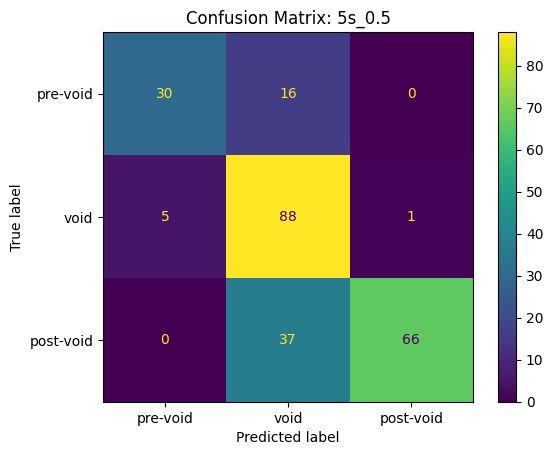

              precision    recall  f1-score   support

    pre-void       0.86      0.65      0.74        46
        void       0.62      0.94      0.75        94
   post-void       0.99      0.64      0.78       103

    accuracy                           0.76       243
   macro avg       0.82      0.74      0.76       243
weighted avg       0.82      0.76      0.76       243

Accuracy: 0.757201646090535


In [28]:
test_state_preds, em, covars = implementation_gaussian(void_probs_exp_ids, n_states=3)
state_preds = test_state_preds['predicted_state'].values

# Confusion matrix
cm = confusion_matrix(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void'])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['pre-void', 'void', 'post-void'])
cm_display.plot()
plt.title(f'Confusion Matrix: 5s_0.5')
plt.show()

# Classification report
print(classification_report(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void']))
print("Accuracy:", accuracy_score(y_test_3_class, state_preds))